# Week 7-2 · DMP-01 — Strategy Back-Testing using Python
**Module:** Data Analysis & Modeling in Python · Instructor: Vivek Krishnamurthy.

The first back-testing lecture. Before any strategy, the lecture nails down four building blocks that recur
everywhere: **simple vs log returns**, **`cumsum` vs `cumprod`**, the **`.shift()` operator (look-ahead bias)**,
and **vectorized vs event-driven** back-testing. Then it builds a **vectorized SMA strategy** end-to-end.

> The lecture downloads live data with `yfinance` (not installed here), so we use the **shipped NSE daily file**
> `nse_daily.csv` (962 bars, 2017-01-02 → 2020-11-27) for the back-test. The concepts are identical.

## The 7-step approach to building a strategy
1. **Idea** — forums, news, blogs, academic studies, gut instinct.
2. **Download data** — daily is easy; intraday (1/5/15-min) via broker.
3. **Algorithm** — indicators → entry/exit rules → returns & P&L in money, not just %.
4. Program **step-wise**, test each part (debugging a whole script is painful).
5. **Comment** your code (your future self thanks you).
6. **Fragment** code (e.g. make the download a function so you don't re-run it).
7. **Contingency plans** — save downloaded data to CSV so a failed download doesn't stop you.

## 0. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
print("pandas", pd.__version__)

pandas 3.0.3


## 1. Simple returns vs log returns
**Simple (arithmetic)** return: $r_t = \dfrac{P_t - P_{t-1}}{P_{t-1}}$ — what we learned in school; **multiplicative** over time.
**Log** return: $\ell_t = \ln\!\big(P_t / P_{t-1}\big)$ — **additive** over time, preferred in stats models.

In [2]:
px = pd.read_csv("nse_daily.csv", index_col=0, parse_dates=True)["Close"]
r      = px.pct_change()              # simple returns
log_r  = np.log(px / px.shift(1))     # log returns
comp = pd.DataFrame({"simple": r, "log": log_r}).dropna()
print(comp.head())
print("\nclose to each other but NOT identical; gap grows as |return| grows")
print("max abs difference:", round((comp['simple']-comp['log']).abs().max(), 5))

              simple       log
Date                          
2017-01-03  0.001559  0.001558
2017-01-04 -0.000214 -0.000214
2017-01-05  0.010170  0.010119
2017-01-06 -0.003626 -0.003632
2017-01-09 -0.000940 -0.000941

close to each other but NOT identical; gap grows as |return| grows
max abs difference: 0.00923


## 2. The multiplicative trap — why you can't just add simple returns
The lecture's worked example: a price path **100 → 105 → 108 → 103 → 106**.

In [3]:
path = [100, 105, 108, 103, 106]
s = pd.Series(path)
rr = s.pct_change().dropna()
print("daily simple returns:")
for i, v in enumerate(rr, 1):
    print(f"  r{i} = {v*100:.3f}%")
print(f"\nWRONG: plain sum of simple returns = {rr.sum()*100:.3f}%   (does not equal truth)")
true_ret = (path[-1]/path[0] - 1)
print(f"TRUE total return 100->106          = {true_ret*100:.3f}%")
cumprod_ret = (1 + rr).prod() - 1
print(f"cumprod (1+r).prod()-1              = {cumprod_ret*100:.3f}%   <- matches truth")

daily simple returns:
  r1 = 5.000%
  r2 = 2.857%
  r3 = -4.630%
  r4 = 2.913%

WRONG: plain sum of simple returns = 6.140%   (does not equal truth)
TRUE total return 100->106          = 6.000%
cumprod (1+r).prod()-1              = 6.000%   <- matches truth


### Log returns ARE additive
Because $\ln\frac{105}{100}+\ln\frac{108}{105}+\ln\frac{103}{108}+\ln\frac{106}{103}=\ln\frac{106}{100}$ (the inner prices cancel).

In [4]:
lr = np.log(s / s.shift(1)).dropna()
print("sum of log returns      =", round(lr.sum(), 6))
print("ln(106/100) directly    =", round(np.log(106/100), 6), " <- identical")
print("convert back to simple  =", round(np.exp(lr.sum()) - 1, 6), "= 6%")

sum of log returns      = 0.058269
ln(106/100) directly    = 0.058269  <- identical
convert back to simple  = 0.06 = 6%


## 3. `cumsum` vs `cumprod` — match the tool to the return type
- **Simple returns → `cumprod`**: cumulative wealth = $\prod(1+r_t)$, then subtract 1.
- **Log returns → `cumsum`**: cumulative log return = $\sum \ell_t$ (just add).

In [5]:
eq_simple = (1 + rr).cumprod() - 1     # cumulative simple return path
eq_log     = lr.cumsum()                # cumulative log return path
print("cumprod path (simple):", [round(x,4) for x in eq_simple.tolist()])
print("cumsum  path (log)   :", [round(x,4) for x in eq_log.tolist()])
print("both end near 6% (0.06 simple, 0.0583 log)")

cumprod path (simple): [0.05, 0.08, 0.03, 0.06]
cumsum  path (log)   : [0.0488, 0.077, 0.0296, 0.0583]
both end near 6% (0.06 simple, 0.0583 log)


## 4. The `.shift()` operator — avoiding look-ahead bias
`series.shift(1)` moves data **down** one row (yesterday's value sits on today's row); `shift(-1)` pulls the
future up. We shift the **position** by 1 so a signal computed on a bar is *acted on next bar* — otherwise we'd
be trading on information we couldn't have had yet (look-ahead bias).

In [6]:
demo = pd.read_csv("nse_daily.csv", index_col=0, parse_dates=True)[["Close"]].head(5).copy()
demo["prev_day (shift 1)"]  = demo["Close"].shift(1)
demo["next_day (shift -1)"] = demo["Close"].shift(-1)
print(demo)

                  Close  prev_day (shift 1)  next_day (shift -1)
Date                                                            
2017-01-02  8179.500000                 NaN          8192.250000
2017-01-03  8192.250000         8179.500000          8190.500000
2017-01-04  8190.500000         8192.250000          8273.799805
2017-01-05  8273.799805         8190.500000          8243.799805
2017-01-06  8243.799805         8273.799805                  NaN


## 5. Vectorized vs event-driven back-testing
| | Vectorized (today) | Event-driven |
|---|---|---|
| Data shape | whole matrix at once | one candle/event at a time (a loop) |
| Speed | very fast (linear algebra / NumPy) | slow, computationally costly |
| Realism | optimistic — ignores fills/slippage | models unfilled/partial orders, slippage, order book |
| Use when | screening many ideas (15 → 2) | final validation of the survivors |

The rest of this notebook is **vectorized**.

## 6. Vectorized SMA strategy (end-to-end)
**Idea:** go long when price is above its 12-period SMA, exit when it drops below. We run it on the real NSE
daily file. Steps: returns → indicator → rule → shift → strategy returns → equity curve.

In [7]:
df = pd.read_csv("nse_daily.csv", index_col=0, parse_dates=True)
df = df[["Close"]].copy()
df["cc_returns"] = df["Close"].pct_change()           # simple returns
SMA = 12
df["SMA"] = df["Close"].rolling(window=SMA).mean()     # rolling mean indicator
df = df.dropna()
print("shape after warm-up:", df.shape)
print(df.head(3))

shape after warm-up: (951, 3)
                  Close  cc_returns          SMA
Date                                            
2017-01-17  8398.000000   -0.001759  8300.291585
2017-01-18  8417.000000    0.002262  8320.083252
2017-01-19  8435.099609    0.002150  8340.320719


### The rule with `np.where`, then `.shift(1)`

In [8]:
# 1 when Close > SMA (long), else 0 (flat)
df["position"] = np.where(df["Close"] > df["SMA"], 1, 0)
print("raw signal counts:\n", df["position"].value_counts())
# shift so we act on the NEXT bar (no look-ahead)
df["position"] = df["position"].shift(1)
df = df.dropna()
print("\ntime long:", int((df['position']==1).sum()),
      "| time flat:", int((df['position']==0).sum()))

raw signal counts:
 position
1    606
0    345
Name: count, dtype: int64

time long: 605 | time flat: 345


### Strategy returns = position x market returns, then compound

In [9]:
df["strategy_returns"] = df["position"] * df["cc_returns"]
df["bh_equity"]  = (1 + df["cc_returns"]).cumprod()       # buy & hold
df["str_equity"] = (1 + df["strategy_returns"]).cumprod() # strategy
bh_total  = df["bh_equity"].iloc[-1]  - 1
str_total = df["str_equity"].iloc[-1] - 1
print(f"Buy & Hold total return : {bh_total*100:.2f}%")
print(f"SMA strategy total return: {str_total*100:.2f}%")
print(f"period: {df.index[0].date()} -> {df.index[-1].date()}")

Buy & Hold total return : 54.43%
SMA strategy total return: 54.46%
period: 2017-01-18 -> 2020-11-27


### Equity curves
The simple SMA strategy here ends up **essentially tied with buy-and-hold** (54.46% vs 54.43%) — it spent ~64%
of the time invested yet captured almost the same return. That near-dead-heat is the instructional point: a
simple idea rarely delivers a clear edge over the benchmark, which is exactly why you back-test before risking
money (the lecture's Nvidia run similarly trailed buy-and-hold).

In [10]:
fig, ax = plt.subplots(figsize=(8,3.6))
ax.plot(df.index, df["bh_equity"],  label="Buy & Hold", color="#9a3412", lw=1.3)
ax.plot(df.index, df["str_equity"], label="SMA-12 strategy", color="#ea580c", lw=1.3)
ax.axhline(1, color="gray", ls="--", lw=0.7)
ax.set_title("NSE — Buy & Hold vs vectorized SMA-12 strategy")
ax.set_ylabel("Growth of 1"); ax.legend(); ax.grid(alpha=0.25)
fig.tight_layout(); fig.savefig("equity_preview.png", dpi=110)
print("equity curve drawn")

equity curve drawn

## Key takeaways
- **Simple vs log returns:** simple = `pct_change` (multiplicative); log = `np.log(P/P.shift(1))` (additive). Close in value, diverging as returns grow; log always slightly *understates* the simple return.
- **Match the tool:** simple returns → **`cumprod`** of `(1+r)` then −1; log returns → **`cumsum`**. The 100→106 path proves plain addition of simple returns (6.13%) is wrong; cumprod gives the true 6%.
- **`.shift(1)`** moves the signal so you trade on the *next* bar — this is how you avoid **look-ahead bias**.
- **Vectorized** back-testing is fast and great for screening many ideas; **event-driven** is slow but realistic (fills, slippage, order book) — use it on the few survivors.
- **The SMA strategy** is built in clean steps: returns → rolling SMA → `np.where` rule → shift → `position * returns` → compound. Here it ends roughly *tied* with buy-and-hold (54.46% vs 54.43%) — no real edge, the honest instructional result.

---
# Additive source-notebook and workbook validation section

# DMP-01 resource addendum

Additive notebook only. It preserves the existing DMP-01 practice notebook and adds the official source notebook/workbook coverage using local files only.

## 1. Source inventory

The tutorial zip includes a full notebook, the NSE daily CSV, and the Excel workbook for log returns versus simple returns.

In [11]:
from pathlib import Path
import numpy as np
import pandas as pd

CODE_DIR = Path('.')
print('nse_daily exists:', (CODE_DIR / 'nse_daily.csv').exists())
display(pd.read_csv('dmp01_source_file_inventory.csv'))
display(pd.read_csv('dmp01_vectorized_workflow_reference.csv'))

nse_daily exists: True


,source_file,size_bytes,local_additive_artifact
0,DMP01-Tutorial-Inclass-Exercises-File/DMP_01_c...,1056771,DMP_01_code_Tutorial Session.ipynb_source_copy
1,DMP01-Tutorial-Inclass-Exercises-File/DMP_01_d...,75044,DMP_01_data_tutorial_nse.csv_source_csv
2,DMP01-Tutorial-Inclass-Exercises-File/Log Retu...,10238,Log Returns vs Simple Returns.xlsx_source_copy


,step,name,lecture_detail
0,1,Strategy idea,State the hypothesis and whether it is long-on...
1,2,Data,Download or load historical data; keep a CSV c...
2,3,Indicators,"Create alpha sources such as SMA, EMA, RSI, Bo..."
3,4,Signals,Encode entry/exit events from the indicators.
4,5,Positions,Carry signals forward and shift positions to a...
5,6,Returns,Multiply returns by positions; use cumprod for...
6,7,Analysis,"Evaluate equity, drawdown, Sharpe, exposure, a..."


## 2. Excel workbook comparison

The workbook demonstrates that simple returns compound by multiplication while log returns add and then convert back with exponentiation.

In [12]:
workbook = pd.read_csv('dmp01_log_simple_workbook_reference.csv')
display(workbook)
last = workbook.iloc[-1]
print('Final simple cumprod return:', round(last['simple_growth_cumprod'] - 1, 6))
print('Final log exp(cumsum) return:', round(last['log_growth_exp_cumsum'] - 1, 6))
print('Plain sum of simple returns:', round(workbook['simple_return'].sum(), 6))

,step,close_price,simple_return,log_return,simple_growth_cumprod,log_growth_exp_cumsum
0,0,250.0,NaN,NaN,1.000,1.000
1,1,245.0,-0.020000,-0.020203,0.980,0.980
2,2,234.0,-0.044898,-0.045937,0.936,0.936
3,3,237.0,0.012821,0.012739,0.948,0.948
4,4,240.0,0.012658,0.012579,0.960,0.960


Final simple cumprod return: -0.04
Final log exp(cumsum) return: -0.04
Plain sum of simple returns: -0.039419


## 3. Long-short SMA crossover

The source notebook formalizes a long-short crossover: long when the short moving average is above the long moving average, short when it is below, and shift the position before applying returns.

In [13]:
metrics = pd.read_csv('dmp01_long_short_crossover_metrics.csv')
display(metrics)
ls = pd.read_csv('dmp01_long_short_crossover_sample.csv', parse_dates=['Date'])
display(ls.tail(5)[['Date', 'Close', 'SMA50', 'SMA200', 'position', 'strategy_equity', 'drawdown']])

,metric,value,units,note
0,source_nse_matches_existing_nse_daily,True,boolean,Official source CSV equals local nse_daily.csv...
1,observations_after_sma200_warmup,763,rows,Rows after 200-day moving average warm-up.
2,long_short_trade_count,6,crossovers,Number of raw SMA50/SMA200 polarity changes.
3,long_exposure_pct,70.7732634338139,percent rows,Share of rows long after shifting position.
4,short_exposure_pct,29.095674967234604,percent rows,Share of rows short after shifting position.
5,buy_hold_total_return_pct,27.816355755934886,percent,Buy-and-hold over same warm-up-adjusted window.
6,long_short_total_return_pct,-52.73363769676883,percent,"Long/short SMA50/SMA200 strategy, shifted one ..."
7,long_short_cagr_pct,-21.92488250617449,percent annualized,Annualized growth assuming 252 trading days.
8,long_short_ann_vol_pct,20.803823135086393,percent annualized,Annualized volatility of strategy returns.
9,long_short_sharpe_0rf,-1.0848654041028893,ratio,Sharpe with zero risk-free rate.


,Date,Close,SMA50,SMA200,position,strategy_equity,drawdown
758,2020-11-23,12926.450195,11862.436973,10731.759766,1.0,0.471115,-0.591240
759,2020-11-24,13055.150391,11894.250977,10737.137266,1.0,0.475805,-0.587170
760,2020-11-25,12858.400391,11922.617988,10740.983516,1.0,0.468635,-0.593392
761,2020-11-26,12987.000000,11951.921992,10745.228765,1.0,0.473321,-0.589325
762,2020-11-27,12968.950195,11979.210000,10749.581768,1.0,0.472664,-0.589896


## 4. Event-style loop equivalence

The event-driven preview checks one new candle at a time. For this simple long-flat SMA12 example, the loop and vectorized shifted-position method produce the same final equity.

In [14]:
event_check = pd.read_csv('dmp01_event_vs_vectorized_check.csv')
display(event_check)
print('Absolute final-equity difference:', event_check.loc[event_check['metric'] == 'absolute_difference', 'value'].iloc[0])

,metric,value,note
0,vector_final_equity,1.544583,Vectorized shifted position equity.
1,loop_final_equity,1.544583,For-loop event-style equity.
2,absolute_difference,0.000000,Should be zero or floating-point noise.
3,matching_positions_pct,100.000000,Position alignment after shifting.


Absolute final-equity difference: 0.0


## 5. Visual references

Charts document the workflow, workbook compounding, long-short crossover, metric snapshot, and event-loop check.

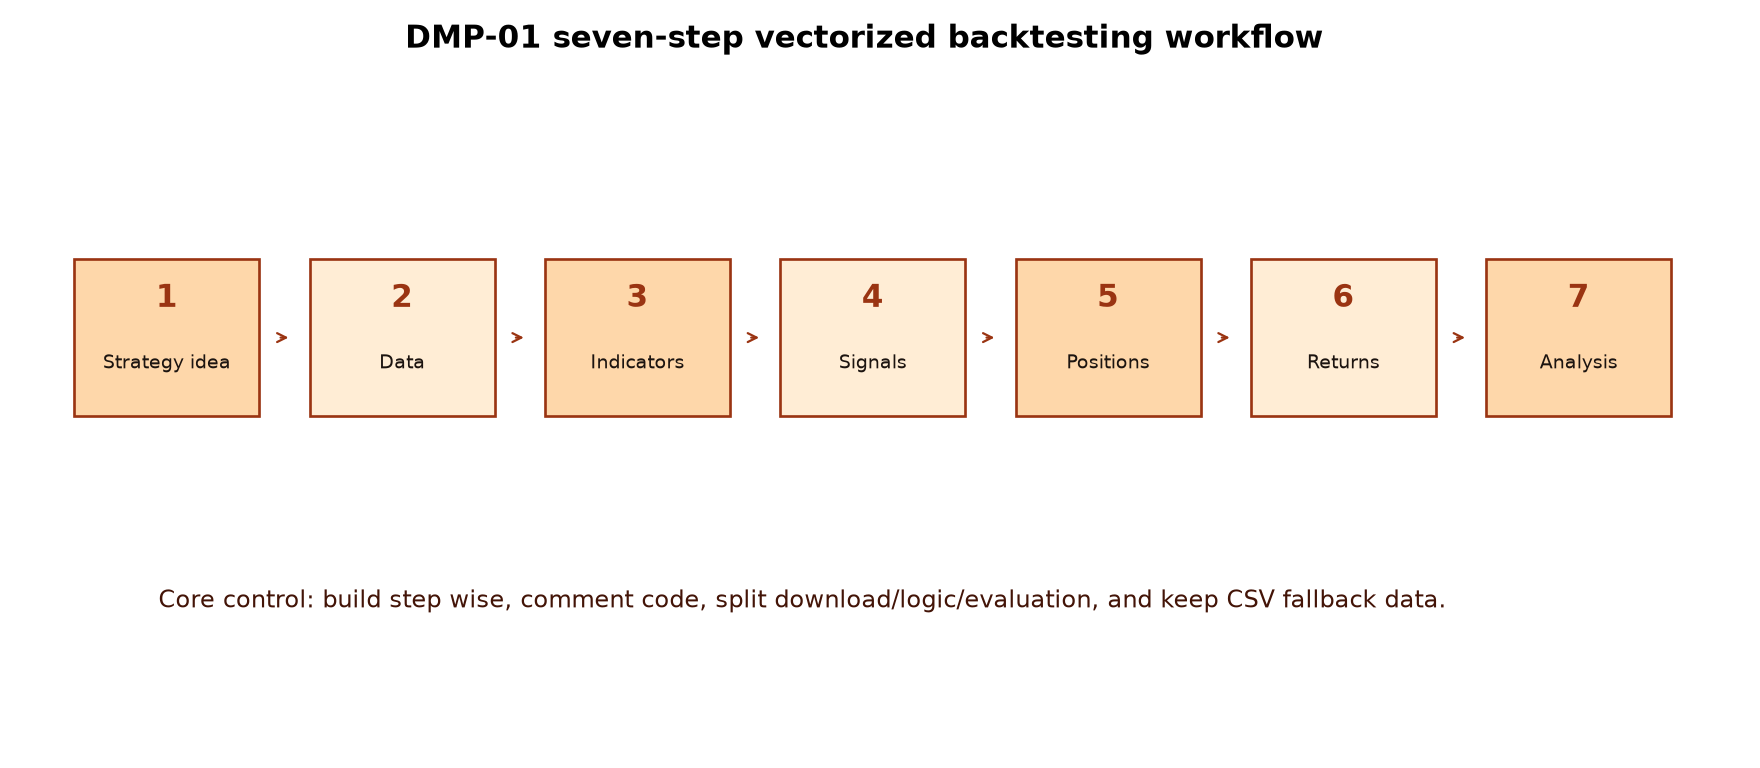

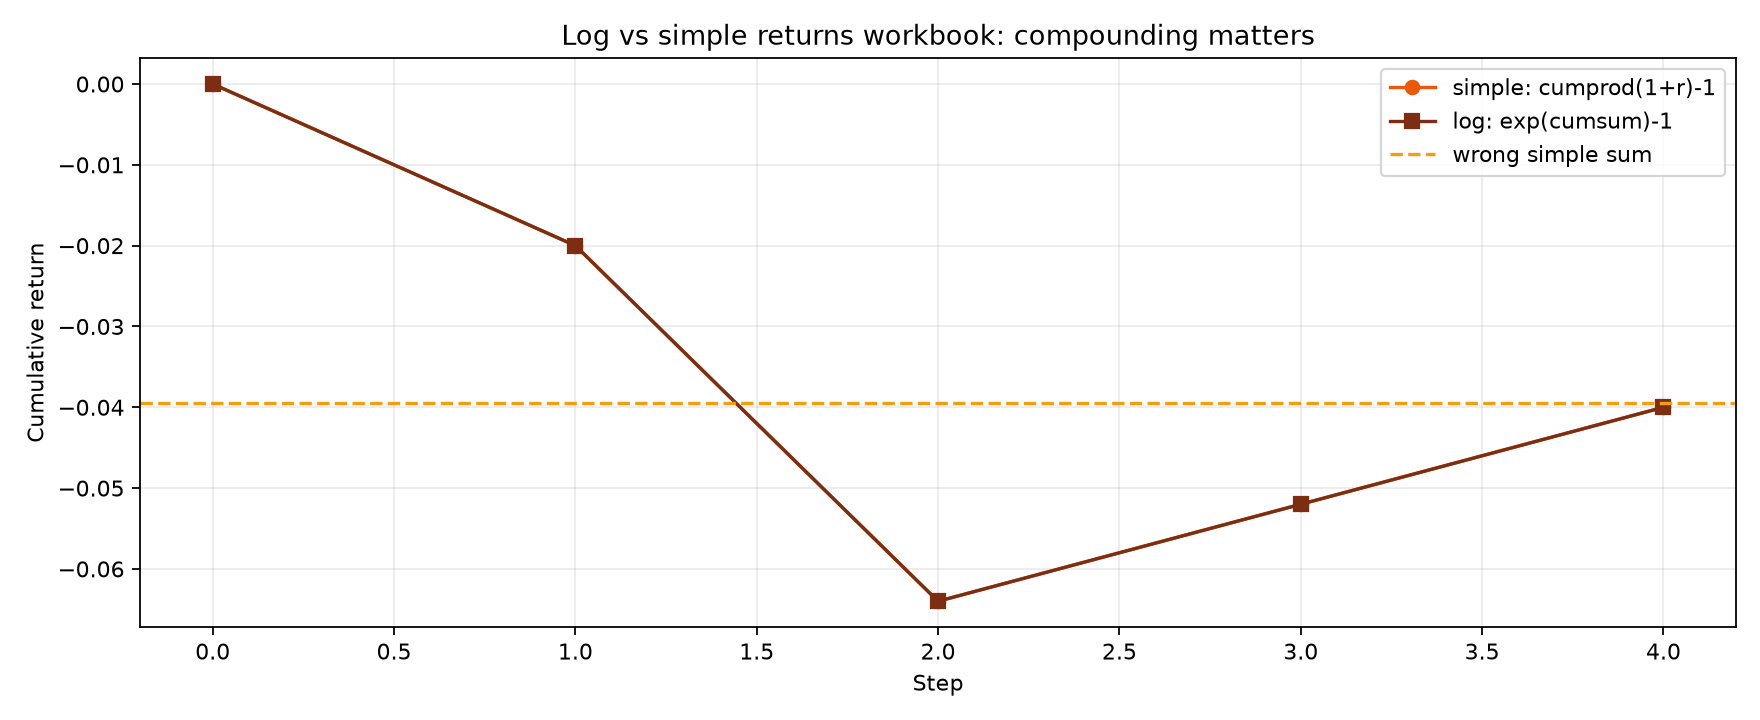

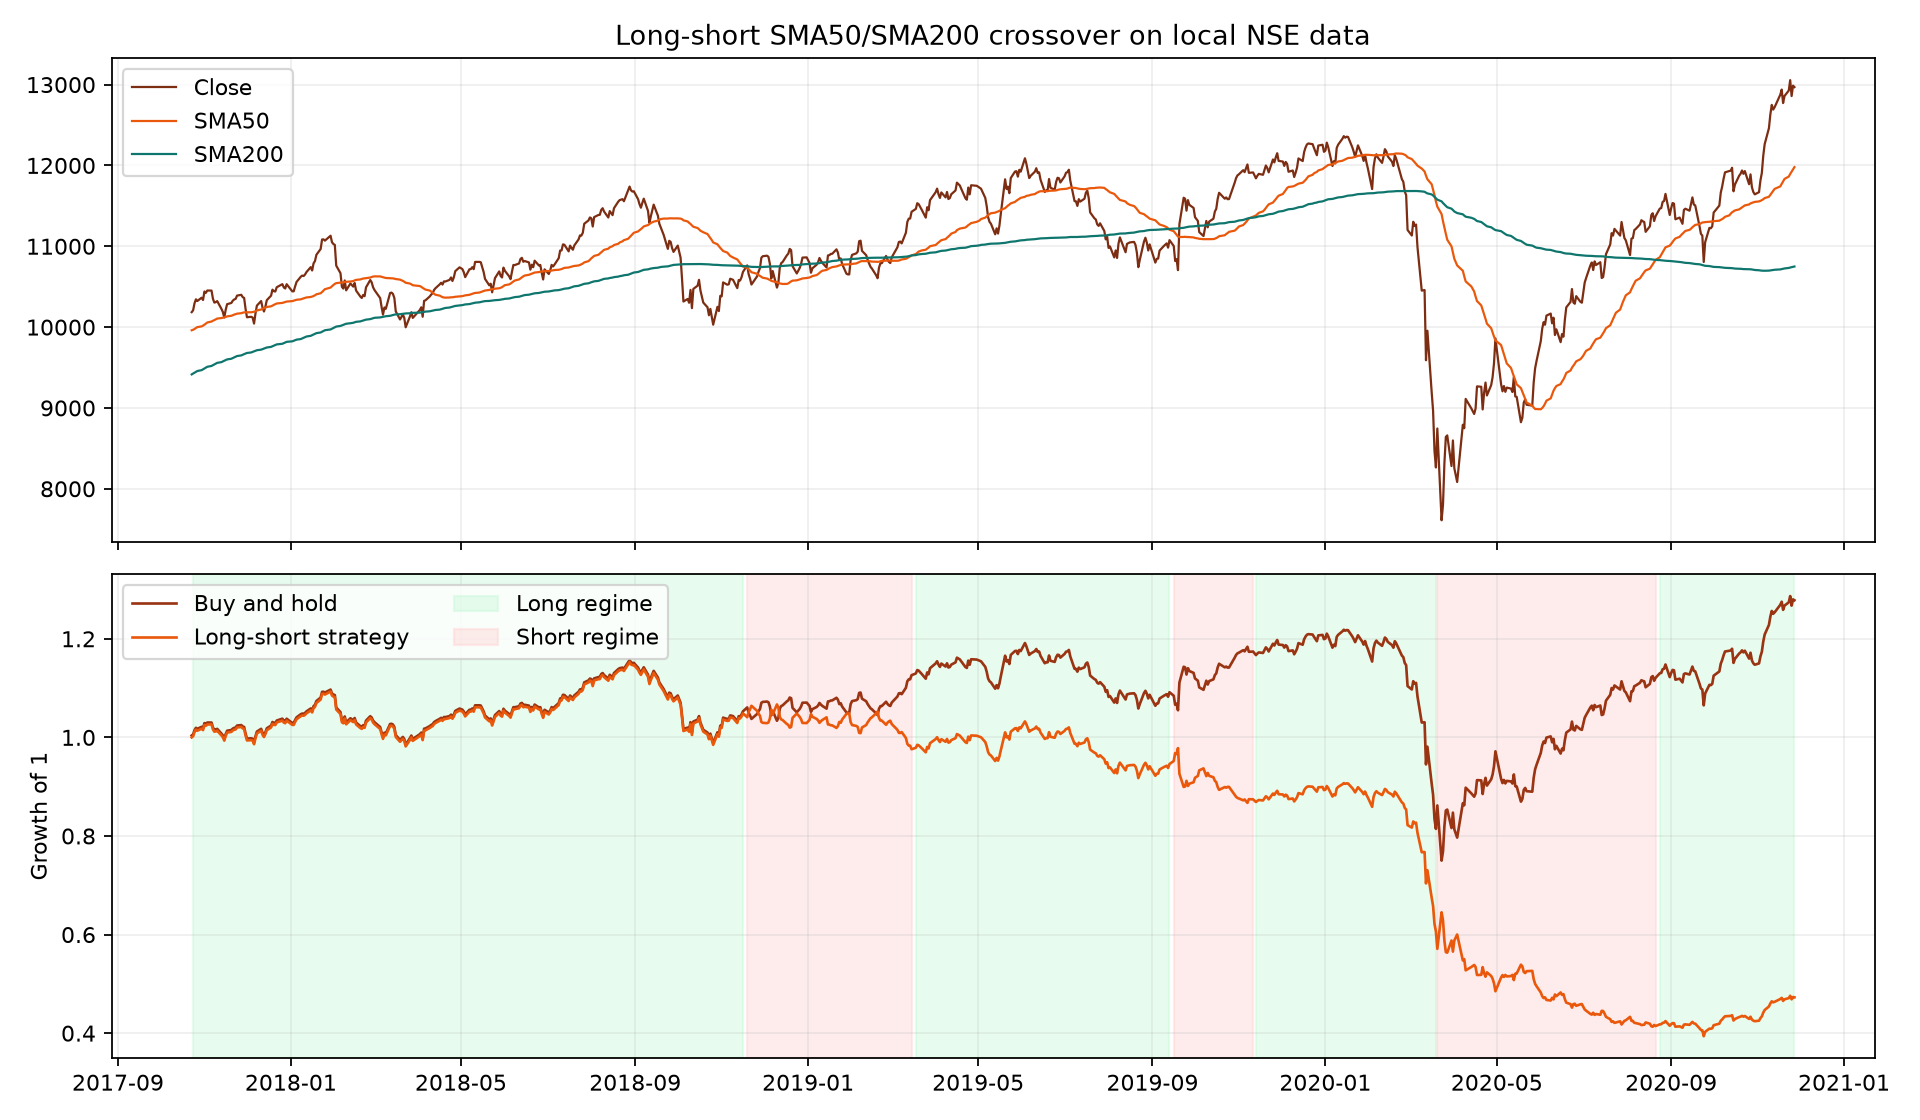

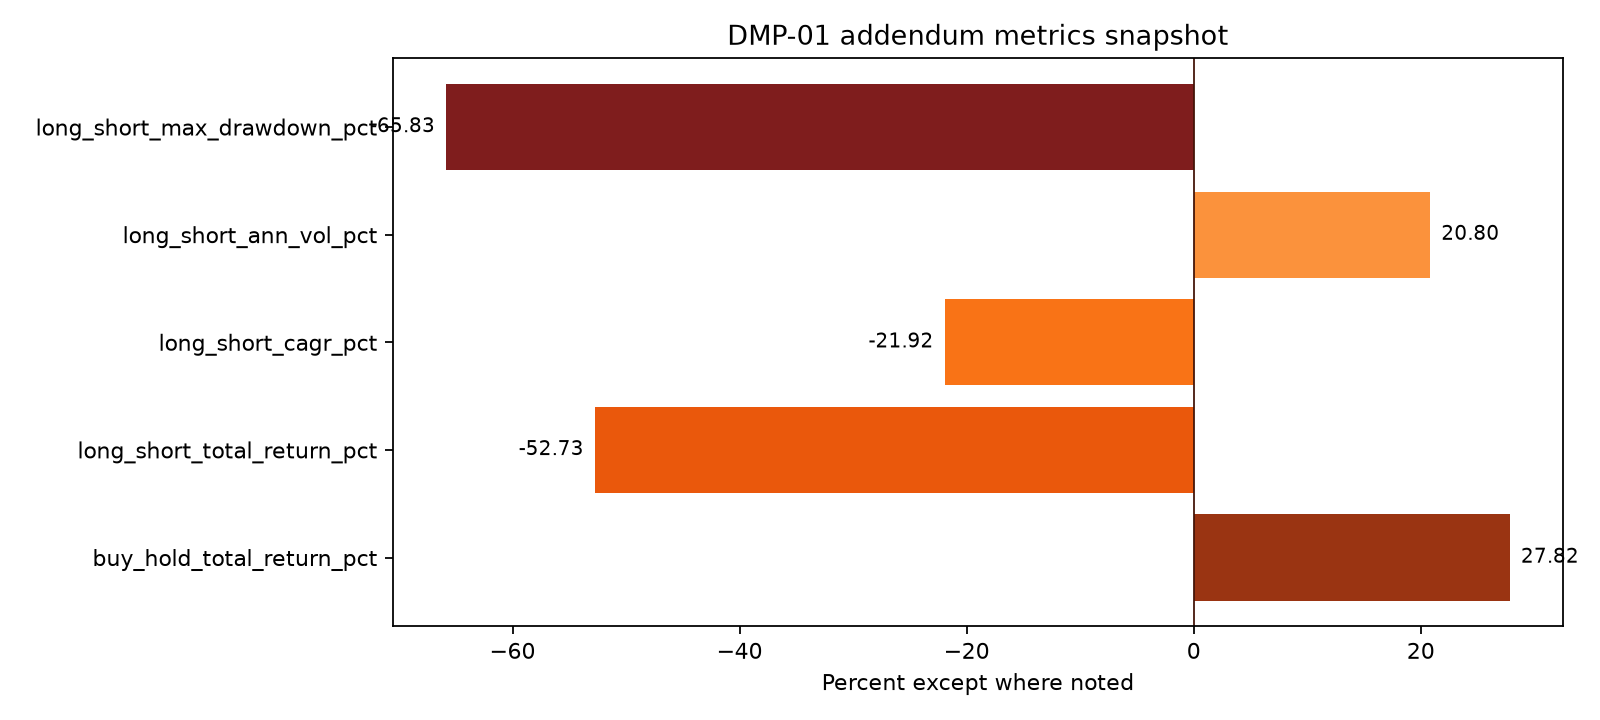

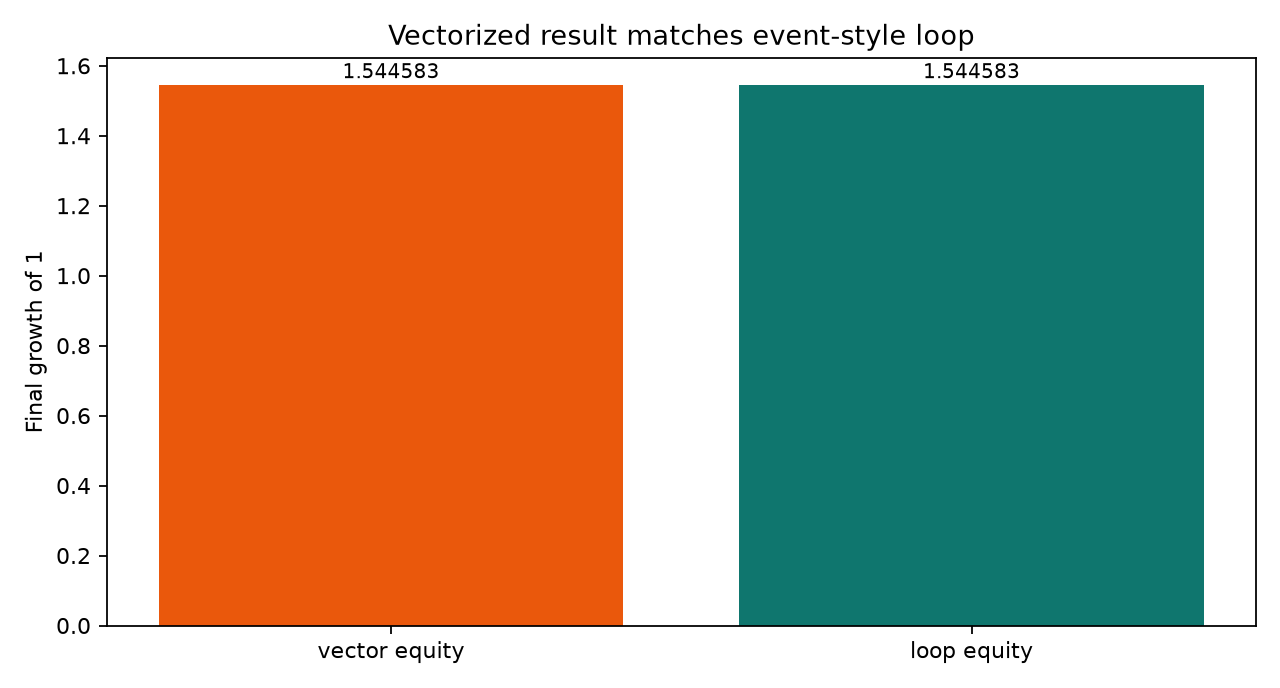

In [15]:
from IPython.display import Image, display
for image in [
    'chart_addendum_1_dmp01_workflow_map.png',
    'chart_addendum_2_dmp01_log_simple_workbook.png',
    'chart_addendum_3_dmp01_long_short_crossover.png',
    'chart_addendum_4_dmp01_metrics_snapshot.png',
    'chart_addendum_5_dmp01_event_loop_check.png',
]:
    display(Image(filename=image))

## 6. Quantstats-style note

Quantstats is not required for this offline pack. The addendum computes a small local tear-sheet proxy: cumulative return, CAGR, annualized volatility, Sharpe, max drawdown, exposure, and trade count.

In [16]:
summary = metrics[metrics['metric'].isin(['long_short_total_return_pct','long_short_cagr_pct','long_short_ann_vol_pct','long_short_sharpe_0rf','long_short_max_drawdown_pct'])]
display(summary[['metric', 'value', 'units']])
print('DMP-01 resource addendum complete')

,metric,value,units
6,long_short_total_return_pct,-52.73363769676883,percent
7,long_short_cagr_pct,-21.92488250617449,percent annualized
8,long_short_ann_vol_pct,20.803823135086393,percent annualized
9,long_short_sharpe_0rf,-1.0848654041028893,ratio
10,long_short_max_drawdown_pct,-65.83068733489132,percent


DMP-01 resource addendum complete
